Imports & Setup

Purpose: load libraries + make runs reproducible

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip install numpy matplotlib seaborn tqdm scikit-learn pandas jupyterlab

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import re
from collections import Counter

from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

torch.manual_seed(42)


c:\Users\snow1\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load ATIS Dataset

Purpose: load intent-labelled aviation queries

In [3]:
dataset = load_dataset("tuetschek/atis")

train_data = dataset["train"]
test_data = dataset["test"]

df_train = pd.DataFrame({
    "text": train_data["text"],
    "intent": train_data["intent"]
})

df_test = pd.DataFrame({
    "text": test_data["text"],
    "intent": test_data["intent"]
})


Select Intent

In [4]:
selected_intents = [
    "flight",
    "airfare",
    "airline",
    "flight_no",
    "flight_time",
    "ground_service",
    "distance",
    "city"
]

df_train = df_train[df_train["intent"].isin(selected_intents)].reset_index(drop=True)
df_test  = df_test[df_test["intent"].isin(selected_intents)].reset_index(drop=True)


Clean Text

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df_train["clean_text"] = df_train["text"].apply(clean_text)
df_test["clean_text"]  = df_test["text"].apply(clean_text)


Build Vocabulary

Purpose: convert words → numbers (required for RNN)

In [6]:
all_words = " ".join(df_train["clean_text"]).split()
word_freq = Counter(all_words)

vocab = {"<PAD>": 0, "<UNK>": 1}
for word in word_freq:
    vocab[word] = len(vocab)

vocab_size = len(vocab)
print("Vocab size:", vocab_size)


Vocab size: 676


Encode Text to Sequences

Purpose: fixed-length sequences for batching

In [7]:
MAX_LEN = 20

def encode_text(text):
    tokens = text.split()
    seq = [vocab.get(w, vocab["<UNK>"]) for w in tokens]
    seq = seq[:MAX_LEN]
    seq += [vocab["<PAD>"]] * (MAX_LEN - len(seq))
    return seq

df_train["encoded"] = df_train["clean_text"].apply(encode_text)
df_test["encoded"]  = df_test["clean_text"].apply(encode_text)


Label Mapping

In [8]:
label2idx = {label: idx for idx, label in enumerate(selected_intents)}
idx2label = {idx: label for label, idx in label2idx.items()}

df_train["label"] = df_train["intent"].map(label2idx)
df_test["label"]  = df_test["intent"].map(label2idx)

num_classes = len(label2idx)
print(label2idx)


{'flight': 0, 'airfare': 1, 'airline': 2, 'flight_no': 3, 'flight_time': 4, 'ground_service': 5, 'distance': 6, 'city': 7}


DataLoaders

In [9]:
X_train = np.array(df_train["encoded"].tolist())
y_train = np.array(df_train["label"].tolist())
X_test  = np.array(df_test["encoded"].tolist())
y_test  = np.array(df_test["label"].tolist())

class IntentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dl = DataLoader(IntentDataset(X_train, y_train), batch_size=32, shuffle=True)
test_dl  = DataLoader(IntentDataset(X_test, y_test), batch_size=32)


Baseline LSTM Model (Iteration 1)

In [10]:
class IntentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])


Train Baseline Model

In [11]:
model_iter1 = IntentLSTM(
    vocab_size=vocab_size,
    embed_dim=100,
    hidden_dim=128,
    num_classes=num_classes
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_iter1.parameters(), lr=0.001)

EPOCHS = 8

for epoch in range(EPOCHS):
    model_iter1.train()
    total_loss = 0

    for Xb, yb in train_dl:
        optimizer.zero_grad()
        out = model_iter1(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_dl):.4f}")


Epoch 1, Loss: 0.9154
Epoch 2, Loss: 0.6824
Epoch 3, Loss: 0.2967
Epoch 4, Loss: 0.1598
Epoch 5, Loss: 0.1007
Epoch 6, Loss: 0.0669
Epoch 7, Loss: 0.0478
Epoch 8, Loss: 0.0463


Evaluate Baseline Model

In [12]:
model_iter1.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for Xb, yb in test_dl:
        out = model_iter1(Xb)
        preds = torch.argmax(out, dim=1)
        y_true.extend(yb.tolist())
        y_pred.extend(preds.tolist())

labels = sorted(set(y_true) | set(y_pred))

print(
    classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=[idx2label[i] for i in labels],
        zero_division=0
    )
)


                precision    recall  f1-score   support

        flight       0.98      1.00      0.99       632
       airfare       1.00      0.98      0.99        48
       airline       0.97      1.00      0.99        38
     flight_no       0.00      0.00      0.00         8
   flight_time       0.17      1.00      0.29         1
ground_service       1.00      1.00      1.00        36
      distance       1.00      0.60      0.75        10
          city       1.00      0.17      0.29         6

      accuracy                           0.98       779
     macro avg       0.77      0.72      0.66       779
  weighted avg       0.97      0.98      0.97       779



Confusion Matrix (Iteration 1)

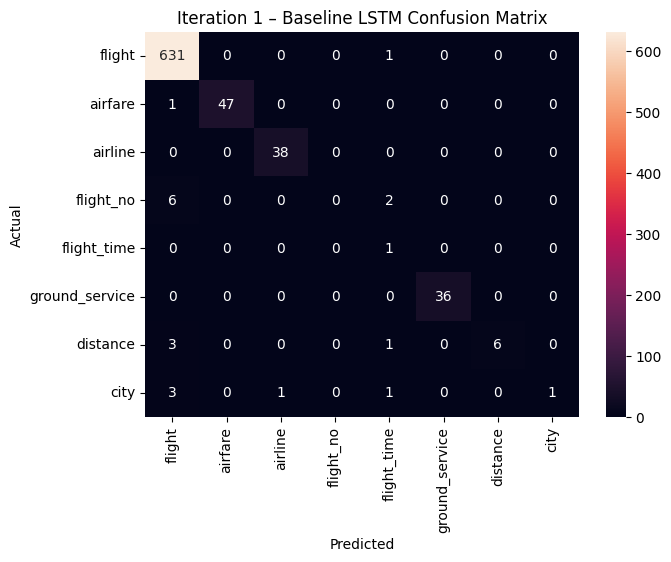

In [13]:
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=[idx2label[i] for i in labels],
    yticklabels=[idx2label[i] for i in labels]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Iteration 1 – Baseline LSTM Confusion Matrix")
plt.show()


#ITERATION 2: LSTM + Dropout


In [14]:
class IntentLSTM_Dropout(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        h_last = self.dropout(h[-1])
        return self.fc(h_last)

#CELL (Iter 2) — Train

In [15]:
model_iter2 = IntentLSTM_Dropout(
    vocab_size=vocab_size,
    embed_dim=100,
    hidden_dim=128,
    num_classes=num_classes,
    dropout=0.3
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_iter2.parameters(), lr=0.001)

EPOCHS = 8

for epoch in range(EPOCHS):
    model_iter2.train()
    total_loss = 0

    for Xb, yb in train_dl:
        optimizer.zero_grad()
        out = model_iter2(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"[Iter2] Epoch {epoch+1}, Loss: {total_loss/len(train_dl):.4f}")


[Iter2] Epoch 1, Loss: 0.8788
[Iter2] Epoch 2, Loss: 0.4482
[Iter2] Epoch 3, Loss: 0.2716
[Iter2] Epoch 4, Loss: 0.1691
[Iter2] Epoch 5, Loss: 0.1132
[Iter2] Epoch 6, Loss: 0.0875
[Iter2] Epoch 7, Loss: 0.0653
[Iter2] Epoch 8, Loss: 0.0693


#CELL (Iter 2) — Evaluate (Classification Report)

In [16]:
model_iter2.eval()
y_true2, y_pred2 = [], []

with torch.no_grad():
    for Xb, yb in test_dl:
        out = model_iter2(Xb)
        preds = torch.argmax(out, dim=1)
        y_true2.extend(yb.tolist())
        y_pred2.extend(preds.tolist())

labels2 = sorted(set(y_true2) | set(y_pred2))

print(
    classification_report(
        y_true2,
        y_pred2,
        labels=labels2,
        target_names=[idx2label[i] for i in labels2],
        zero_division=0
    )
)


                precision    recall  f1-score   support

        flight       0.98      0.99      0.98       632
       airfare       1.00      0.96      0.98        48
       airline       0.86      1.00      0.93        38
     flight_no       0.00      0.00      0.00         8
   flight_time       0.50      1.00      0.67         1
ground_service       0.90      0.97      0.93        36
      distance       0.71      0.50      0.59        10
          city       0.00      0.00      0.00         6

      accuracy                           0.96       779
     macro avg       0.62      0.68      0.63       779
  weighted avg       0.95      0.96      0.95       779



#CELL (Iter 2) — Confusion Matrix

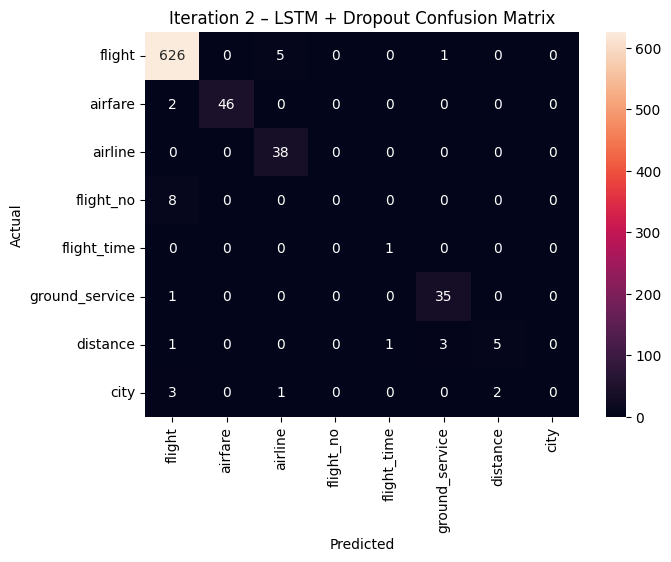

In [17]:
cm2 = confusion_matrix(y_true2, y_pred2, labels=labels2)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm2, annot=True, fmt="d",
    xticklabels=[idx2label[i] for i in labels2],
    yticklabels=[idx2label[i] for i in labels2]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Iteration 2 – LSTM + Dropout Confusion Matrix")
plt.show()


#CELL (Iter 2) — Quick Compare to Iter 1 Accuracy

In [18]:
from sklearn.metrics import accuracy_score

print("Iter1 accuracy:", accuracy_score(y_true, y_pred))
print("Iter2 accuracy:", accuracy_score(y_true2, y_pred2))


Iter1 accuracy: 0.975609756097561
Iter2 accuracy: 0.9640564826700898


# ITERATION 3: BiLSTM

In [19]:
class IntentBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        # h shape: (num_directions, batch, hidden_dim) = (2, batch, hidden_dim)
        h_forward = h[-2]   # forward last hidden
        h_backward = h[-1]  # backward last hidden
        h_cat = torch.cat((h_forward, h_backward), dim=1)
        h_cat = self.dropout(h_cat)
        return self.fc(h_cat)


#CELL (Iter 3) — Train

In [20]:
model_iter3 = IntentBiLSTM(
    vocab_size=vocab_size,
    embed_dim=100,
    hidden_dim=128,
    num_classes=num_classes,
    dropout=0.3
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_iter3.parameters(), lr=0.001)

EPOCHS = 8

for epoch in range(EPOCHS):
    model_iter3.train()
    total_loss = 0

    for Xb, yb in train_dl:
        optimizer.zero_grad()
        out = model_iter3(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"[Iter3] Epoch {epoch+1}, Loss: {total_loss/len(train_dl):.4f}")


[Iter3] Epoch 1, Loss: 0.5637
[Iter3] Epoch 2, Loss: 0.1529
[Iter3] Epoch 3, Loss: 0.0751
[Iter3] Epoch 4, Loss: 0.0415
[Iter3] Epoch 5, Loss: 0.0213
[Iter3] Epoch 6, Loss: 0.0115
[Iter3] Epoch 7, Loss: 0.0088
[Iter3] Epoch 8, Loss: 0.0060


#CELL (Iter 3) — Evaluate (Classification Report)

In [21]:
model_iter3.eval()
y_true3, y_pred3 = [], []

with torch.no_grad():
    for Xb, yb in test_dl:
        out = model_iter3(Xb)
        preds = torch.argmax(out, dim=1)
        y_true3.extend(yb.tolist())
        y_pred3.extend(preds.tolist())

labels3 = sorted(set(y_true3) | set(y_pred3))

print(
    classification_report(
        y_true3,
        y_pred3,
        labels=labels3,
        target_names=[idx2label[i] for i in labels3],
        zero_division=0
    )
)


                precision    recall  f1-score   support

        flight       0.98      1.00      0.99       632
       airfare       0.86      1.00      0.92        48
       airline       0.97      0.97      0.97        38
     flight_no       1.00      0.62      0.77         8
   flight_time       1.00      1.00      1.00         1
ground_service       0.95      1.00      0.97        36
      distance       0.00      0.00      0.00        10
          city       0.00      0.00      0.00         6

      accuracy                           0.97       779
     macro avg       0.72      0.70      0.70       779
  weighted avg       0.95      0.97      0.96       779



#CELL (Iter 3) — Confusion Matrix

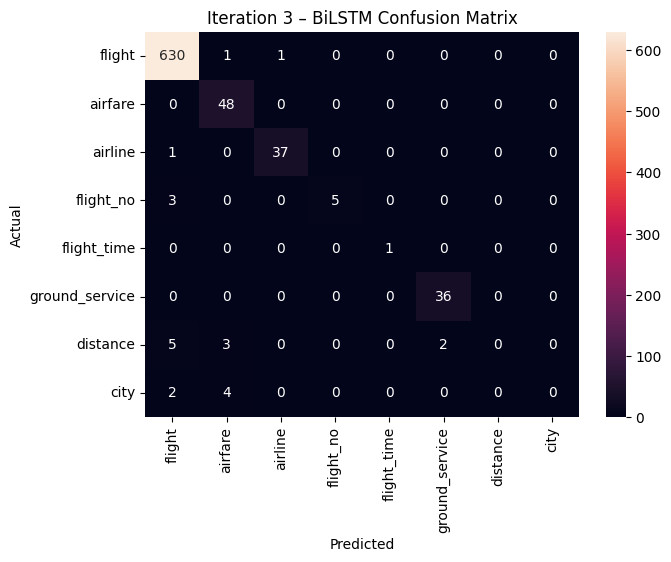

In [22]:
cm3 = confusion_matrix(y_true3, y_pred3, labels=labels3)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm3, annot=True, fmt="d",
    xticklabels=[idx2label[i] for i in labels3],
    yticklabels=[idx2label[i] for i in labels3]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Iteration 3 – BiLSTM Confusion Matrix")
plt.show()


#CELL (Iter 3) — Compare Accuracies (Iter1 vs Iter2 vs Iter3)

In [23]:
from sklearn.metrics import accuracy_score

print("Iter1 accuracy:", accuracy_score(y_true, y_pred))
print("Iter2 accuracy:", accuracy_score(y_true2, y_pred2))
print("Iter3 accuracy:", accuracy_score(y_true3, y_pred3))


Iter1 accuracy: 0.975609756097561
Iter2 accuracy: 0.9640564826700898
Iter3 accuracy: 0.9717586649550706


#Misclassification Examples (Iteration 3)

In [24]:
count = 0
for i, (t, p) in enumerate(zip(y_true3, y_pred3)):
    if t != p:
        print("TEXT:", df_test.loc[i, "text"])
        print("TRUE:", idx2label[t], " | PRED:", idx2label[p])
        print("-"*70)
        count += 1
        if count == 10:
            break


TEXT: to what cities from boston does america west fly first class
TRUE: city  | PRED: airfare
----------------------------------------------------------------------
TEXT: how far is new york 's la guardia from downtown
TRUE: distance  | PRED: flight
----------------------------------------------------------------------
TEXT: how far is toronto international from downtown
TRUE: distance  | PRED: airfare
----------------------------------------------------------------------
TEXT: how far is los angeles international from downtown
TRUE: distance  | PRED: airfare
----------------------------------------------------------------------
TEXT: how far is san francisco international from downtown
TRUE: distance  | PRED: airfare
----------------------------------------------------------------------
TEXT: how long does a flight from baltimore to san francisco take
TRUE: distance  | PRED: flight
----------------------------------------------------------------------
TEXT: list the distance in miles